In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [30]:

data = pd.read_csv('data (1).csv')




In [31]:
print(data.isnull().sum())


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [32]:
data.drop(['Unnamed: 32', 'id'], axis=1, inplace=True , errors='ignore')
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

In [33]:
y = data['diagnosis'].values
x_data = data.drop(['diagnosis'], axis=1)

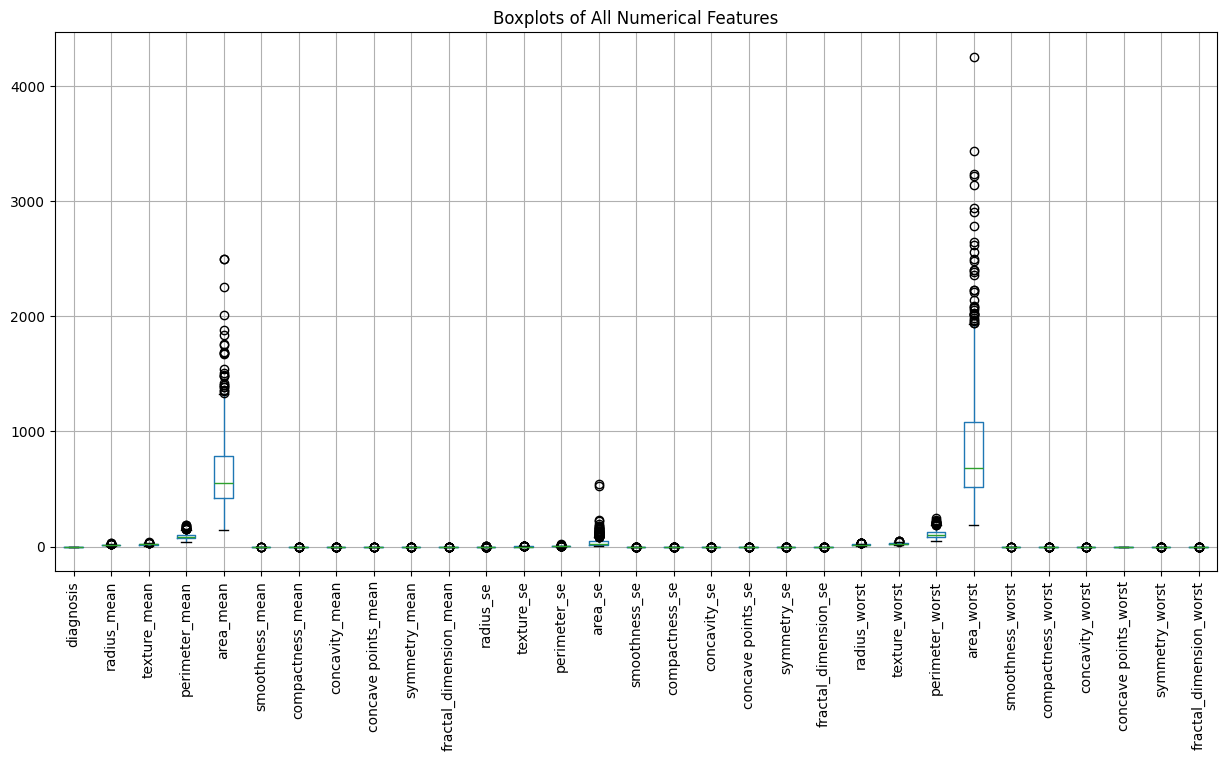

In [34]:
plt.figure(figsize=(15, 7))
data.boxplot()
plt.title("Boxplots of All Numerical Features")
plt.xticks(rotation=90)
plt.show()

Columns chosen for selective standardization: ['area_mean', 'perimeter_mean', 'area_worst', 'perimeter_worst']

 Standardization applied ONLY to selected outlier-heavy columns.



C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


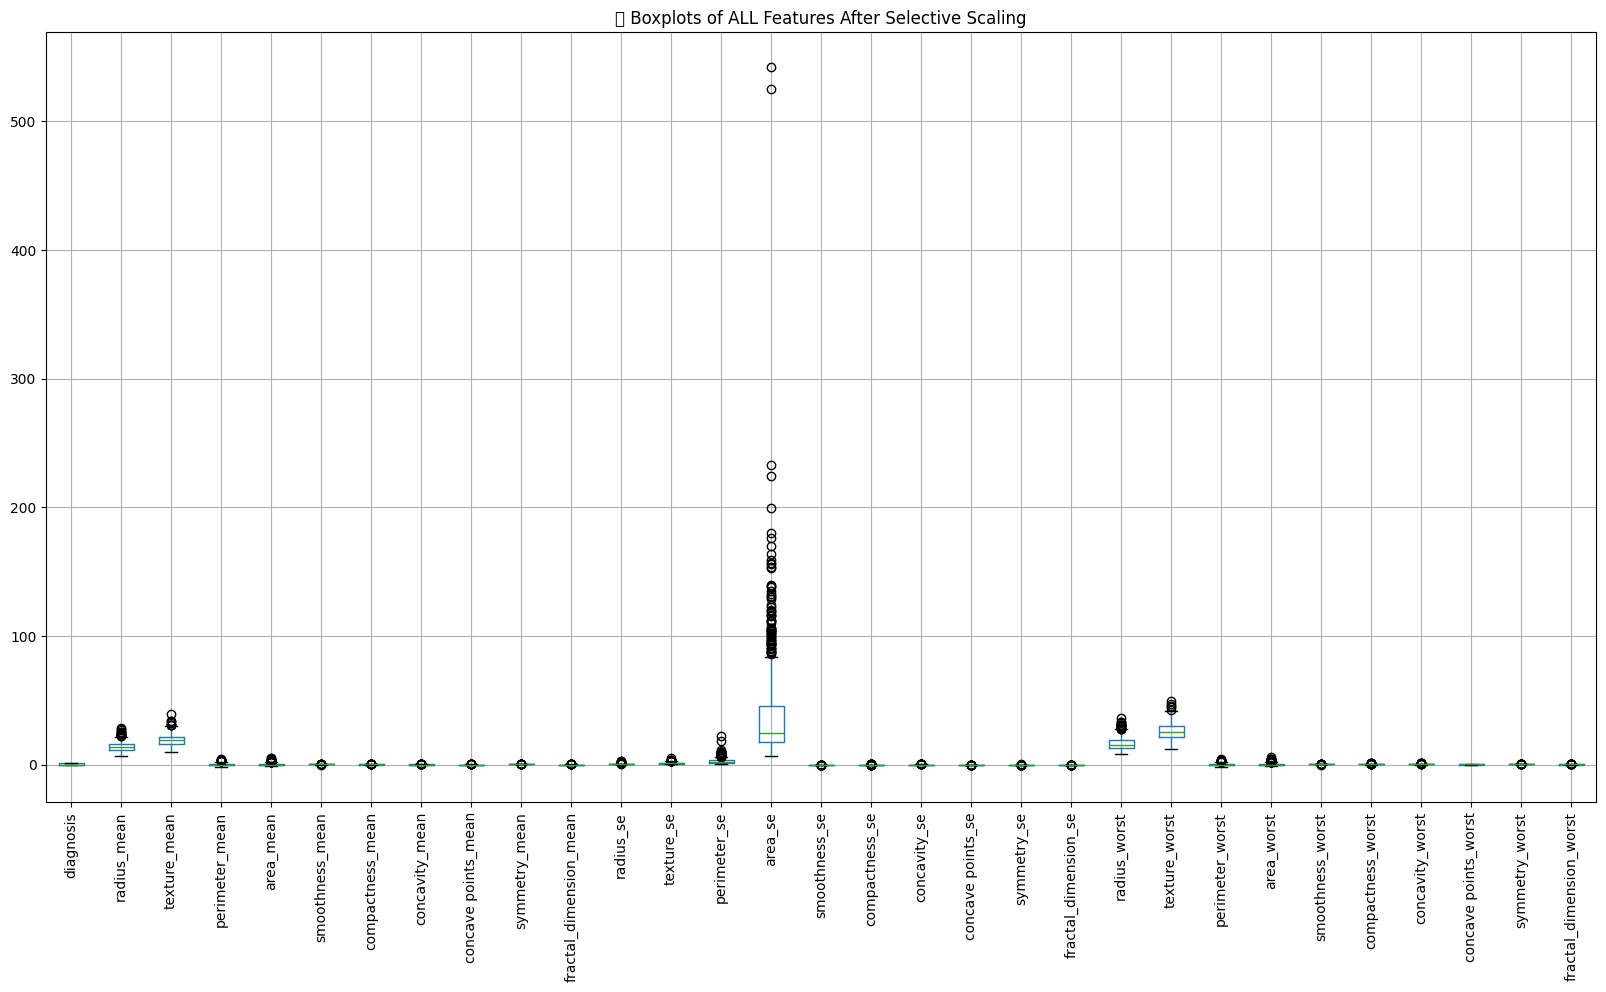

In [35]:
outlier_columns = [
    'area_mean',
    'perimeter_mean',
    'area_worst',
    'perimeter_worst'
]

print("Columns chosen for selective standardization:", outlier_columns)


scaler = StandardScaler()
data_scaled = data.copy()
data_scaled[outlier_columns] = scaler.fit_transform(data[outlier_columns])
print("\n Standardization applied ONLY to selected outlier-heavy columns.\n")


plt.figure(figsize=(20, 10))
data_scaled.boxplot()
plt.title("📉 Boxplots of ALL Features After Selective Scaling")
plt.xticks(rotation=90)
plt.show()

In [36]:
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.690000,0.428813,0.678668,0.566490,0.526948,0.296055,0.571462,0.690358,0.336364,0.132056,...,0.623266,0.383262,0.576174,0.452664,0.461137,0.178527,0.328035,0.761512,0.097575,0.105667
565,0.622320,0.626987,0.604036,0.474019,0.407782,0.257714,0.337395,0.486630,0.349495,0.113100,...,0.560655,0.699094,0.520892,0.379915,0.300007,0.159997,0.256789,0.559450,0.198502,0.074315
566,0.455251,0.621238,0.445788,0.303118,0.288165,0.254340,0.216753,0.263519,0.267677,0.137321,...,0.393099,0.589019,0.379949,0.230731,0.282177,0.273705,0.271805,0.487285,0.128721,0.151909
567,0.644564,0.663510,0.665538,0.475716,0.588336,0.790197,0.823336,0.755467,0.675253,0.425442,...,0.633582,0.730277,0.668310,0.402035,0.619626,0.815758,0.749760,0.910653,0.497142,0.452315


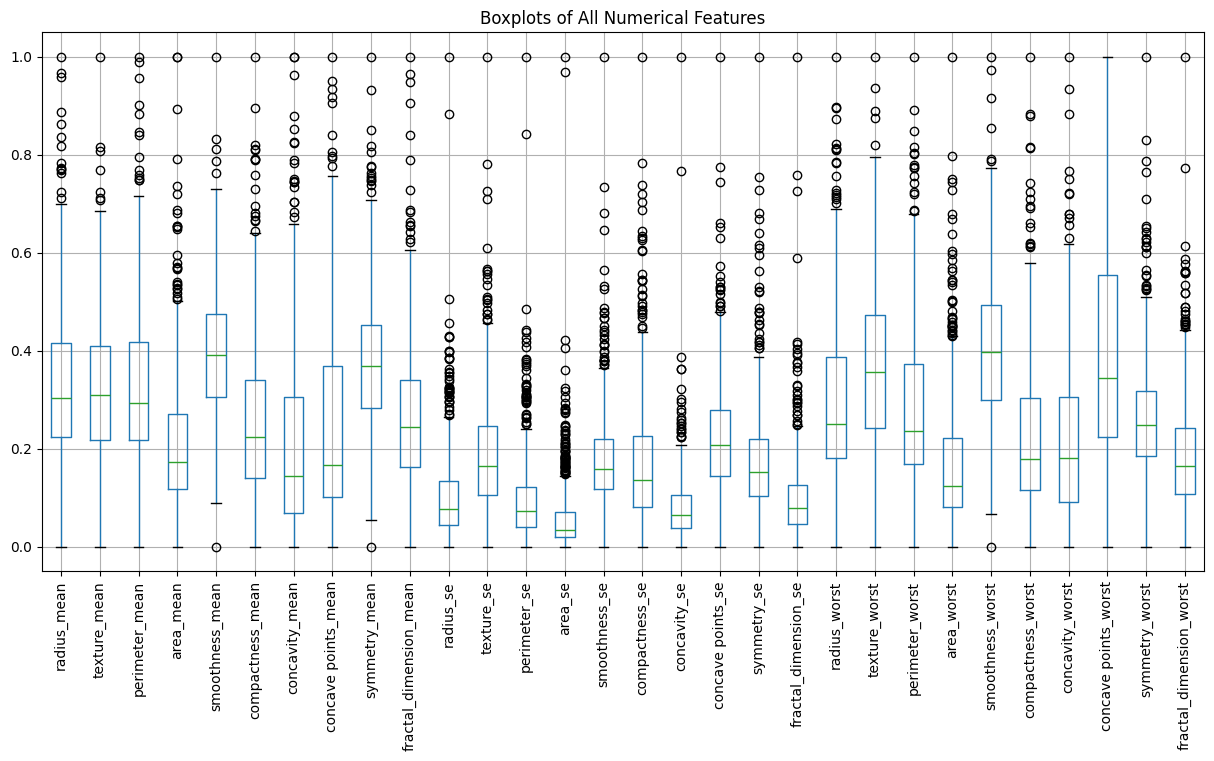

In [37]:
plt.figure(figsize=(15, 7))

x.boxplot(rot=90)
plt.title("Boxplots of All Numerical Features")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split


train_data, temp_data = train_test_split(
    data_scaled,
    test_size=0.70,            
    random_state=42,
    stratify=data_scaled['diagnosis']
)


test1_data, test2_data = train_test_split(
    temp_data,
    test_size=0.5,             
    random_state=42,
    stratify=temp_data['diagnosis']
)


print(f"Train: {train_data.shape}, Test1: {test1_data.shape}, Test2: {test2_data.shape}")


X_train = train_data.drop('diagnosis', axis=1).values
y_train = train_data['diagnosis'].values.reshape(-1, 1)

X_test1 = test1_data.drop('diagnosis', axis=1).values
y_test1 = test1_data['diagnosis'].values.reshape(-1, 1)

X_test2 = test2_data.drop('diagnosis', axis=1).values
y_test2 = test2_data['diagnosis'].values.reshape(-1, 1)


X_train_bias = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test1_bias = np.c_[np.ones((X_test1.shape[0], 1)), X_test1]
X_test2_bias = np.c_[np.ones((X_test2.shape[0], 1)), X_test2]

print("\n Data successfully split into 30% Train, 35% Test1, and 35% Test2.\n")


Train: (170, 31), Test1: (199, 31), Test2: (200, 31)

✅ Data successfully split into 30% Train, 35% Test1, and 35% Test2.



In [47]:

print(" Training Gaussian Naive Bayes Model...")
gnb = GaussianNB()
gnb.fit(X_train, y_train)
print(" Model Training Complete!\n")

 Training Gaussian Naive Bayes Model...
 Model Training Complete!



C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [48]:
y_pred_train = gnb.predict(X_train)
y_pred_test1 = gnb.predict(X_test1)
y_pred_test2 = gnb.predict(X_test2)

In [49]:
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f" {dataset_name} Evaluation Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}\n")

  
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malignant (1)'])
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.show()

    return acc, prec, rec, f1


 Training Data Evaluation Metrics:
Accuracy : 0.9294
Precision: 0.9180
Recall   : 0.8889
F1-Score : 0.9032



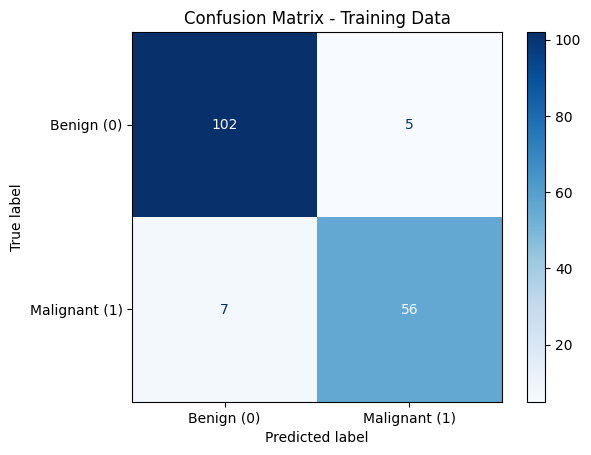

 Test1 Data Evaluation Metrics:
Accuracy : 0.9497
Precision: 0.9444
Recall   : 0.9189
F1-Score : 0.9315



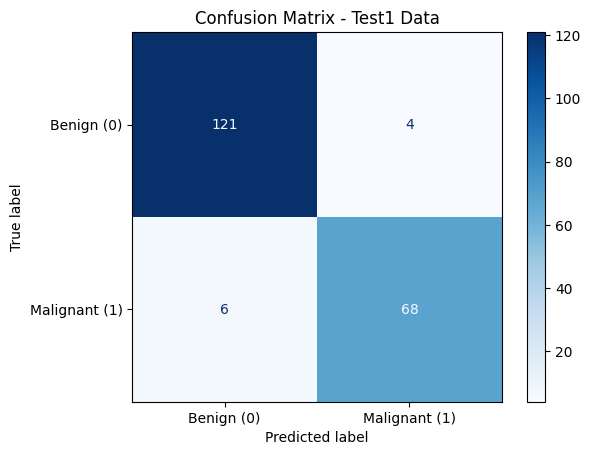

 Test2 Data Evaluation Metrics:
Accuracy : 0.9350
Precision: 0.9306
Recall   : 0.8933
F1-Score : 0.9116



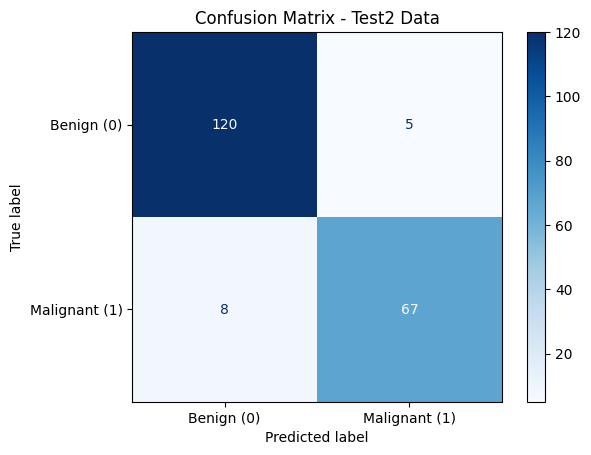

In [50]:
metrics_train = evaluate_model(y_train, y_pred_train, "Training Data")
metrics_test1 = evaluate_model(y_test1, y_pred_test1, "Test1 Data")
metrics_test2 = evaluate_model(y_test2, y_pred_test2, "Test2 Data")

In [51]:

results = pd.DataFrame({
    'Dataset': ['Train', 'Test1', 'Test2'],
    'Accuracy': [metrics_train[0], metrics_test1[0], metrics_test2[0]],
    'Precision': [metrics_train[1], metrics_test1[1], metrics_test2[1]],
    'Recall': [metrics_train[2], metrics_test1[2], metrics_test2[2]],
    'F1-Score': [metrics_train[3], metrics_test1[3], metrics_test2[3]],
})

print("📊 Summary of Model Performance:\n")
results

📊 Summary of Model Performance:



,Dataset,Accuracy,Precision,Recall,F1-Score
0,Train,0.929412,0.918033,0.888889,0.903226
1,Test1,0.949749,0.944444,0.918919,0.931507
2,Test2,0.935000,0.930556,0.893333,0.911565
